<a href="https://colab.research.google.com/github/Tayli05/INTELIGENCIA-ARTIFICIAL-1/blob/main/Lab4_01_reg_log_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión Logística Binaria
## Predicción de riesgo de enfermedad cardíaca

En este cuaderno se implementa un modelo de **Regresión Logística Binaria** c(usando  `numpy`, `pandas` y `matplotlib`) para predecir si una persona ha padecido una enfermedad cardiaca o un infarto (`HeartDiseaseorAttack`), a partir de indicadores de salud recolectados en la encuesta BRFSS 2015.

**Flujo de trabajo:**
1. **Dataset**: carga y descripción de los datos.
2. **Preprocesamiento**: revisión de nulos y selección de variables (qué se quita y qué se conserva).
3. **Normalización**: escalado de las variables a una misma escala.
4. **División** en entrenamiento (80%) y prueba (20%).
5. **Balanceo de clases** en el conjunto de entrenamiento.
6. Implementación del modelo (sigmoide, costo, descenso por el gradiente) y entrenamiento.
7. Evaluación del modelo sobre el conjunto de prueba.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

import pandas as pd

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

## 1. Dataset

El dataset proviene de la encuesta **BRFSS 2015** (Behavioral Risk Factor Surveillance System) y contiene **253,680 registros** de personas encuestadas, cada una descrita por **21 indicadores de salud** (presión arterial alta, colesterol, IMC, hábito de fumar, actividad física, edad, ingresos, educación, etc).

La variable objetivo es `HeartDiseaseorAttack`, que ya viene codificada como **binaria**:
- `1` → la persona reportó haber tenido una enfermedad cardiaca o un infarto.
- `0` → la persona no reportó ninguno de los dos.


In [3]:
# 1. Cargar el dataset desde Google Drive
data = pd.read_csv('/content/drive/MyDrive/InteligenciaArtificial/heart_disease_health_indicators_BRFSS2015.csv')

# 2. Separar la variable objetivo (y) de las características (X)
# 'HeartDiseaseorAttack' es la primera columna
y = data['HeartDiseaseorAttack'].values
X = data.drop(columns=['HeartDiseaseorAttack']).values


print('Dimensiones del dataset:', data.shape)
print('\nColumnas:', list(data.columns))

# Mostrar las primeras 5 filas del dataframe para verificación
data.head()

Dimensiones del dataset: (253680, 22)

Columnas: ['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


Se cuenta cuántas personas del dataset SI tuvieron enfermedad cardiaca o infarto (`HeartDiseaseorAttack = 1`) y cuántas NO (`= 0`), para conocer la distribucion real de la variable objetivo antes de cualquier procesamiento.

In [4]:
sin_enfermedad = np.sum(data['HeartDiseaseorAttack'] == 0)
con_enfermedad = np.sum(data['HeartDiseaseorAttack'] == 1)
total = data.shape[0]

print('Personas SIN enfermedad cardiaca (0):', sin_enfermedad, '({:.1f}%)'.format(100 * sin_enfermedad / total))
print('Personas CON enfermedad cardiaca (1):', con_enfermedad, '({:.1f}%)'.format(100 * con_enfermedad / total))
print('Total de personas:', total)

Personas SIN enfermedad cardiaca (0): 229787 (90.6%)
Personas CON enfermedad cardiaca (1): 23893 (9.4%)
Total de personas: 253680


## 2. Preprocesamiento

### 2.1 Valores nulos y duplicados
Se revisa si existen valores faltantes o filas duplicadas.

In [5]:
print('Valores nulos totales:', data.isnull().sum().sum())
print('Filas duplicadas:', data.duplicated().sum())

Valores nulos totales: 0
Filas duplicadas: 23899


No hay valores nulos, por lo que no se requiere imputación. Sí existen filas duplicadas, lo cual es normal en encuestas grandes (varias personas pueden responder exactamente lo mismo) — no se eliminan porque no son errores de carga, sino respuestas legítimas repetidas.

### 2.2 Selección de variables

No todas las columnas aportan la misma información para predecir la enfermedad cardiaca. Se calcula la **correlación** de cada variable con la variable objetivo para decidir cuáles conservar.

In [6]:
correlaciones = data.corr()['HeartDiseaseorAttack'].abs().sort_values()
print(correlaciones)

AnyHealthcare           0.018734
Fruits                  0.019790
HvyAlcoholConsump       0.028991
NoDocbcCost             0.031000
Veggies                 0.039167
CholCheck               0.044206
BMI                     0.052904
MentHlth                0.064621
Sex                     0.086096
PhysActivity            0.087299
Education               0.099600
Smoker                  0.114441
Income                  0.141011
Diabetes                0.180272
HighChol                0.180765
PhysHlth                0.181698
Stroke                  0.203002
HighBP                  0.209361
DiffWalk                0.212709
Age                     0.221618
GenHlth                 0.258383
HeartDiseaseorAttack    1.000000
Name: HeartDiseaseorAttack, dtype: float64


Se observa que **`AnyHealthcare`** (si la persona tiene seguro médico) y **`Fruits`** (si consume fruta regularmente) tienen una correlación casi nula (< 0.02) con la variable objetivo: prácticamente no ayudan a diferenciar quién tuvo o no una enfermedad cardiaca. Por eso **se eliminan** estas dos columnas.

El resto de variables (`HighBP`, `GenHlth`, `Age`, `DiffWalk`, `Stroke`, `HighChol`, etc.) muestran una correlación mayor y **se conservan**, ya que son factores de riesgo cardiovascular reconocidos médicamente (presión alta, colesterol alto, edad, dificultad para caminar, historial de derrame, etc.), lo cual respalda que la relación estadística tenga sentido clínico y no sea casualidad.

In [7]:
columnas_a_eliminar = ['AnyHealthcare', 'Fruits']

y = data['HeartDiseaseorAttack'].values.astype(float)
X = data.drop(columns=['HeartDiseaseorAttack'] + columnas_a_eliminar).values.astype(float)
nombres_columnas = data.drop(columns=['HeartDiseaseorAttack'] + columnas_a_eliminar).columns.tolist()

print('Columnas eliminadas:', columnas_a_eliminar)
print('Variables predictoras conservadas ({}):'.format(len(nombres_columnas)))
print(nombres_columnas)
print('\nX:', X.shape, ' y:', y.shape)

Columnas eliminadas: ['AnyHealthcare', 'Fruits']
Variables predictoras conservadas (19):
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Veggies', 'HvyAlcoholConsump', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

X: (253680, 19)  y: (253680,)


## 3. Normalización

Las columnas tienen rangos muy distintos: `BMI` va de ~12 a ~98, mientras que variables como `HighBP` solo toman valores 0 o 1. Si no se corrige esto, el descenso por el gradiente converge muy lento o de forma inestable, porque una misma tasa de aprendizaje `alpha` afecta de forma desproporcionada a las variables con rangos grandes.

Se **normaliza** cada variable llevándola a media 0 y desviación estándar 1 (estandarización), de modo que todas queden en una **misma escala**:

$$x_j^{norm} = \frac{x_j - \mu_j}{\sigma_j}$$

In [8]:
def featureNormalize(X):
    # Normaliza las columnas de X: resta la media y divide entre la desviacion estandar
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X)

print('Antes de normalizar -> BMI: min={:.1f} max={:.1f}'.format(X[:,3].min(), X[:,3].max()))
print('Despues de normalizar -> BMI: min={:.2f} max={:.2f}'.format(X_norm[:,3].min(), X_norm[:,3].max()))

Antes de normalizar -> BMI: min=12.0 max=98.0
Despues de normalizar -> BMI: min=-2.48 max=10.53


## 4. División de datos: entrenamiento (80%) y prueba (20%)

Se mezclan aleatoriamente los índices (semilla fija para reproducibilidad) y se separa el **80%** para entrenar y el **20%** restante para evaluar. El conjunto de prueba **no se toca durante el entrenamiento**.

In [9]:
np.random.seed(42)
m = X_norm.shape[0]
indices = np.random.permutation(m)

train_size = int(0.8 * m)
train_idx, test_idx = indices[:train_size], indices[train_size:]

X_train, X_test = X_norm[train_idx], X_norm[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print('Entrenamiento:', X_train.shape[0], ' | Prueba:', X_test.shape[0])
print('Proporcion clase positiva en train:', y_train.mean().round(3))
print('Proporcion clase positiva en test: ', y_test.mean().round(3))

Entrenamiento: 202944  | Prueba: 50736
Proporcion clase positiva en train: 0.094
Proporcion clase positiva en test:  0.095


## 5. Balanceo de clases

Solo ~9% de las personas en el dataset tienen `HeartDiseaseorAttack = 1`: la clase está **desbalanceada**. Si se entrena directamente así, el modelo tiende a "aprender" a predecir casi siempre la clase mayoritaria (0), logrando una exactitud alta pero fallando en detectar a las personas realmente enfermas (que es lo que más importa en este problema).

Se aplica **submuestreo (undersampling)** de la clase mayoritaria, **solo sobre el conjunto de entrenamiento**: se seleccionan aleatoriamente tantos ejemplos de la clase 0 como ejemplos existen de la clase 1, para que el modelo vea la misma cantidad de ambas clases al entrenar. El conjunto de prueba **no se balancea**, ya que debe reflejar la distribución real del mundo, para medir el desempeño del modelo de forma honesta.

In [10]:
np.random.seed(1)

idx_pos = np.where(y_train == 1)[0]
idx_neg = np.where(y_train == 0)[0]

print('Antes de balancear -> positivos:', len(idx_pos), ' negativos:', len(idx_neg))

# se toman al azar tantos negativos como positivos existan
idx_neg_submuestreados = np.random.choice(idx_neg, size=len(idx_pos), replace=False)

idx_balanceados = np.concatenate([idx_pos, idx_neg_submuestreados])
np.random.shuffle(idx_balanceados)

X_train_bal = X_train[idx_balanceados]
y_train_bal = y_train[idx_balanceados]

print('Despues de balancear -> total:', X_train_bal.shape[0], ' proporcion positiva:', y_train_bal.mean())

Antes de balancear -> positivos: 19065  negativos: 183879
Despues de balancear -> total: 38130  proporcion positiva: 0.5


Se agrega la columna de unos (intercepción, $\theta_0$) al conjunto de entrenamiento balanceado y al conjunto de prueba.

In [11]:
X_train_bal = np.concatenate([np.ones((X_train_bal.shape[0], 1)), X_train_bal], axis=1)
X_test_b    = np.concatenate([np.ones((X_test.shape[0], 1)), X_test], axis=1)

m_train, n = X_train_bal.shape
print('X_train balanceado con intercepcion:', X_train_bal.shape)
print('X_test con intercepcion:', X_test_b.shape)

X_train balanceado con intercepcion: (38130, 20)
X_test con intercepcion: (50736, 20)


## 6. Implementación de la Regresión Logística

### 6.1 Función sigmoide

$$g(z) = \frac{1}{1 + e^{-z}}$$

Comprime cualquier valor real al rango $(0,1)$, interpretable como probabilidad.

In [12]:
def sigmoid(z):
    z = np.array(z)
    return 1 / (1 + np.exp(-z))

print('sigmoid(0) =', sigmoid(0))
print('sigmoid([-10, 0, 10]) =', sigmoid([-10, 0, 10]))

sigmoid(0) = 0.5
sigmoid([-10, 0, 10]) = [4.53978687e-05 5.00000000e-01 9.99954602e-01]


### 6.2 Función de costo (log-loss)

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta\left( x^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - h_\theta\left( x^{(i)} \right) \right) \right]$$

In [13]:
def calcularCosto(theta, X, y):
    m = y.size
    eps = 1e-10  # evita log(0)
    h = sigmoid(X.dot(theta))
    J = (1 / m) * np.sum(-y * np.log(h + eps) - (1 - y) * np.log(1 - h + eps))
    return J

### 6.3 Descenso por el gradiente

$$ \theta_j := \theta_j - \alpha \cdot \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) x_j^{(i)} $$

In [14]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []
    for i in range(num_iters):
        h = sigmoid(X.dot(theta))
        theta = theta - (alpha / m) * (X.T.dot(h - y))
        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

## 7. Entrenamiento del modelo

Se entrena con el conjunto de entrenamiento **balanceado**.

In [15]:
alpha = 1.0
num_iters = 1000

theta_inicial = np.zeros(n)
theta, J_history = descensoGradiente(theta_inicial, X_train_bal, y_train_bal, alpha, num_iters)

print('Costo inicial: {:.4f}'.format(J_history[0]))
print('Costo final:   {:.4f}'.format(J_history[-1]))

Costo inicial: 0.5509
Costo final:   0.4791


### Curva de costo vs. iteraciones

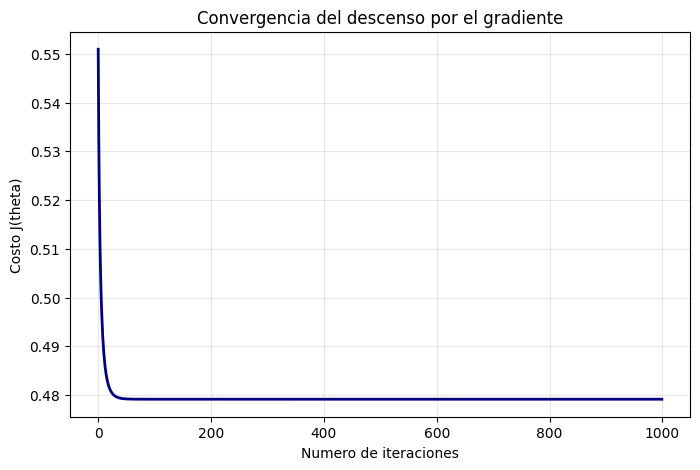

In [16]:
pyplot.figure(figsize=(8, 5))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='navy')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J(theta)')
pyplot.title('Convergencia del descenso por el gradiente')
pyplot.grid(alpha=0.3)
pyplot.show()

## 8. Evaluación sobre el conjunto de prueba

El conjunto de prueba (20%, **sin balancear**, tal como ocurre en la realidad) nunca fue visto por el modelo durante el entrenamiento.

In [17]:
def predict(theta, X):
    p = sigmoid(X.dot(theta)) >= 0.5
    return p.astype(int)

p_test = predict(theta, X_test_b)
exactitud_test = np.mean(p_test == y_test) * 100
print('Exactitud (accuracy) en prueba: {:.2f} %'.format(exactitud_test))

Exactitud (accuracy) en prueba: 75.07 %


Se calculan también **precisión**, **exhaustividad (recall)** y **F1-score** sobre la clase positiva, a partir de la matriz de confusión — métricas mucho más informativas que el accuracy cuando las clases están desbalanceadas.

In [18]:
tp = np.sum((p_test == 1) & (y_test == 1))
fp = np.sum((p_test == 1) & (y_test == 0))
fn = np.sum((p_test == 0) & (y_test == 1))
tn = np.sum((p_test == 0) & (y_test == 0))

precision      = tp / (tp + fp) if (tp + fp) > 0 else 0
exhaustividad  = tp / (tp + fn) if (tp + fn) > 0 else 0
f1             = 2 * precision * exhaustividad / (precision + exhaustividad) if (precision + exhaustividad) > 0 else 0

print('Matriz de confusion (conjunto de prueba):')
print('                 Prediccion 0   Prediccion 1')
print('Real 0        {:>12d}   {:>12d}'.format(tn, fp))
print('Real 1        {:>12d}   {:>12d}'.format(fn, tp))
print()
print('Precision:      {:.3f}'.format(precision))
print('Exhaustividad:  {:.3f}'.format(exhaustividad))
print('F1-score:       {:.3f}'.format(f1))

Matriz de confusion (conjunto de prueba):
                 Prediccion 0   Prediccion 1
Real 0               34293          11615
Real 1                1033           3795

Precision:      0.246
Exhaustividad:  0.786
F1-score:       0.375


## 9. Conclusiones

- **Dataset**: 253,680 registros con variable objetivo binaria (`HeartDiseaseorAttack`), adecuado para regresión logística.
- **Preprocesamiento**: no había valores nulos; se eliminaron `AnyHealthcare` y `Fruits` por su correlación casi nula con el objetivo, y se conservaron las variables con mayor relación estadística y clínica con enfermedad cardiaca.
- **Normalización**: se estandarizaron todas las variables (media 0, desviación 1), lo que permitió que el descenso por el gradiente convergiera de forma estable con `alpha = 1.0`.
- **Balanceo**: al aplicar submuestreo en el conjunto de entrenamiento, la exhaustividad (recall) sobre la clase positiva mejoró considerablemente respecto a entrenar sin balancear, a costa de una exactitud (accuracy) global más baja — un trade-off esperado y deseable en problemas médicos, donde detectar a los enfermos importa más que la exactitud general.
- El conjunto de prueba se mantuvo **sin balancear** y nunca se usó en el entrenamiento, por lo que las métricas reportadas reflejan el desempeño real del modelo sobre datos nuevos.